In [3]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

Pour toute la suite, on se place sur un certain espace probabilisé $(\Omega, \mathcal F, \mathbb P)$. 

# 1) Les bases 

Dans cette section, on voit quelques outils de base sur Python qui peuvent s'avérer pratiques (voire essentiels) pour la modé. 

## 1.1) Gérer des arrays 

Tout d'abord, voilà quelques outils de base pour manier des arrays numpy. Certains des "gadgets" présentés ici ne sont pas indispensables (il y a même sûrement des programmes dans la suite qui ne les utilisent pas alors qu'ils pourraient), mais ça peut toujours être pratique pour gagner du temps ! 

In [3]:
a=np.zeros(5) #vecteur de taille 5 rempli de 0 
b=np.ones(5) #vecteur de taille 5 rempli de 1 
#On peut faire la même chose avec des matrices: 
A,B=np.zeros((5,5)),np.ones((5,5))
#Matrice identité: 
C=np.eye(5) 
#tableau des nombres entre 1 et n avec np.arange: 
D=np.arange(1,26) 
#Pour redimensionner un tableau: 
D=D.reshape((5,5))
print(D)
#Pour construire une matrice diagonale à partir d'un vecteur diagonal donné: 
E=np.diag(np.arange(1,6))
# Et puis les commandes pour accéder aux différents éléments d'une matrice avec quelques exemples sur la matrice D: 
print(D[0,:]) #sa première ligne
print(D[:2,:]) #ses deux premières lignes
print(D[:,0]) #sa première colonne
print(D[:,-1]) #sa dernière colonne
print(D[-1,-1]) #l'élement en bas à droite
print(D[:2,:2]) #le deuxième mineur principal 
# Enfin, ça peut être utile, la commande pour inverser l'ordre d'un vecteur: 
v=np.linspace(1,5,25) #np.linspace(start,stop,num) 
w=v[::-1]
# et la commande pour trouver les indices d'un tableau qui ont une valeur qu'on se fixe: 
x=stats.randint.rvs(low=0, high=9, size=50)
print(x)
y=np.where(x==0)[0] #renvoie un array avec la liste d'indices 
print(y)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]
[1 2 3 4 5]
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]
[ 1  6 11 16 21]
[ 5 10 15 20 25]
25
[[1 2]
 [6 7]]
[6 0 6 5 2 5 7 1 0 1 4 7 7 8 5 4 2 1 8 8 4 3 2 7 0 0 5 5 1 2 4 8 0 4 0 3 0
 0 8 6 0 8 1 0 1 7 7 5 1 5]
[ 1  8 24 25 32 34 36 37 40 43]


## 1.2) Tracer des graphiques 

Maintenant, quelque chose d'ESSENTIEL pour les simulations de modé: les graphiques. Déjà, un premier basique : savoir tracer une simple courbe, mais BIEN LEGENDEE: (pour des tracés en 3D, cf TP2 mais ce n'est pas essentiel selon moi) 

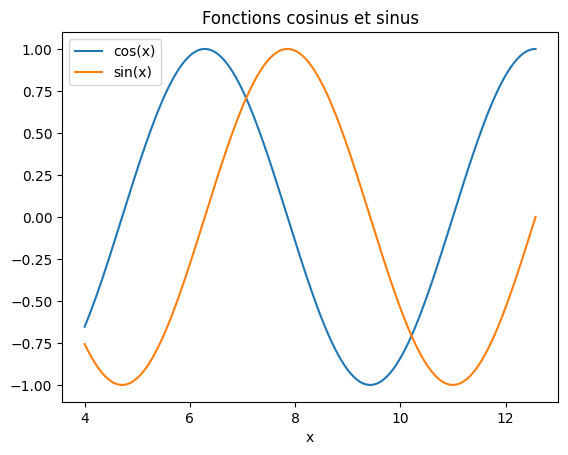

In [33]:
X=np.linspace(4,4*pi,150)
Y=np.cos(X)
Z=np.sin(X)
plt.xlabel('x')
plt.plot(X,Y,label='cos(x)')
plt.plot(X,Z,label='sin(x)')
plt.title('Fonctions cosinus et sinus')
plt.legend()
plt.show()

Ensuite, TRES important, savoir tracer un histogramme (souvent à comparer avec une densité de référence): 

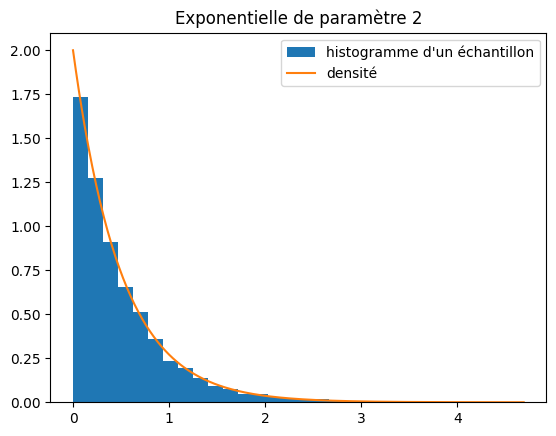

In [29]:
X=stats.expon.rvs(scale=0.5, size=10000)
plt.hist(X,bins=30, density=True, label="histogramme d'un échantillon")
T=np.arange(0,max(X), 0.01)
plt.plot(T,stats.expon.pdf(T, scale=0.5), label="densité")
plt.title("Exponentielle de paramètre 2")
plt.legend()
plt.show()

Utile aussi dans le contexte des lois discrètes, tracer des diagrammes bâtons: 

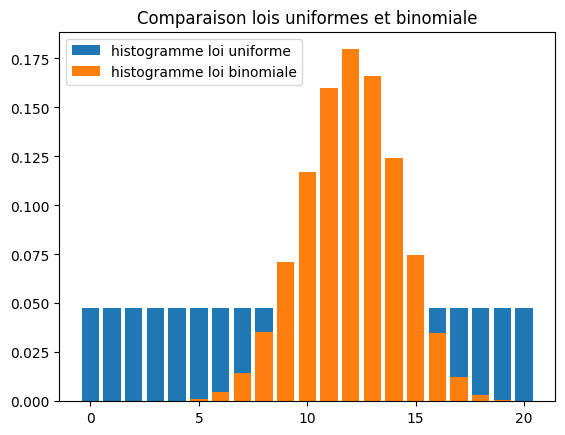

In [175]:
T=np.arange(0,21) 
X=stats.binom.pmf(T,20,0.6)
Y=stats.randint.pmf(T,0,21)
plt.bar(T,Y,label='histogramme loi uniforme')
plt.bar(T,X,label='histogramme loi binomiale')
plt.title('Comparaison lois uniformes et binomiale')
plt.legend()
plt.show()

Enfin, autre capacité utile pour les illustrations de convergence: savoir tracer une fonction en escalier (PAR EXEMPLE, une fonction de répartition empirique, à tout hasard): 

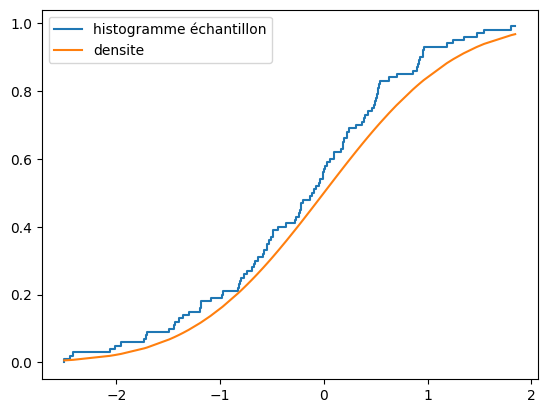

In [39]:
n=100
X=stats.norm.rvs(loc=0,scale=1, size=n)
X_tri=np.sort(X)
plt.plot(X_tri,np.arange(n)/n,drawstyle='steps-pre',label='histogramme échantillon') # ça, c'est vraiment LA commande magique à retenir !!!!!
plt.plot(X_tri,stats.norm.cdf(X_tri), label='densite')
plt.legend()
plt.show()

On reverra tout cela par la suite, parce que toutes ces méthodes vont être utilisées à tord et à travers pour illustrer des convergences. 

# 2) Illustrer des convergences (HYPER IMPORTANT)

Cette partie est (selon moi) LA PLUS IMPORTANTE !! Dans quasiment tous les textes, on peut caser des illustrations de convergence, et ça c'est super, parce que déjà c'est facile à faire, et en plus ça permet parfois de tendre des perches pour des questions pas trop dures sur vos simulations ou sur les théorèmes limites que vous connaissez par coeur ! 

## 2.1) Illustrer une convergence presque-sûre 

Faisons un exemple avec l'illustration de l'incontournable loi des grands nombres : on se donne $(X_i)_{i \ge 1}$ une suite de variables aléatoires iid et $L^1$, de moyenne $\mu $. On a alors la convergence presque sûre suivante: 
$$\frac{S_n}{n} \xrightarrow[n \to \infty]{\text{p.s.}} \mu, $$
où $S_n= \displaystyle \sum_{i=1}^n X_i $. 

Pour faire un exemple, nous allons prendre des variables de loi exponentielle de paramètre $\lambda$, et donc de moyenne $\frac{1}{\lambda}$. La convergence presque sûre étant préservée par applications de fonctions continues, on a alors la convergence suivante: 
$$\frac{n}{S_n} \xrightarrow[n \to \infty]{\text{p.s.}} \lambda. $$

Pour illustrer cette convergence, on travaille TRAJECTOIRE PAR TRAJECTOIRE : on simule un vecteur $[X_1, \dots, X_n]$ où les $X_i$ sont des variables exponentielles de paramètre $\lambda$, et puis on trace les $k/S_k$ en fonction de $k$, où $S_k= \displaystyle \sum_{i=1}^k X_i $.

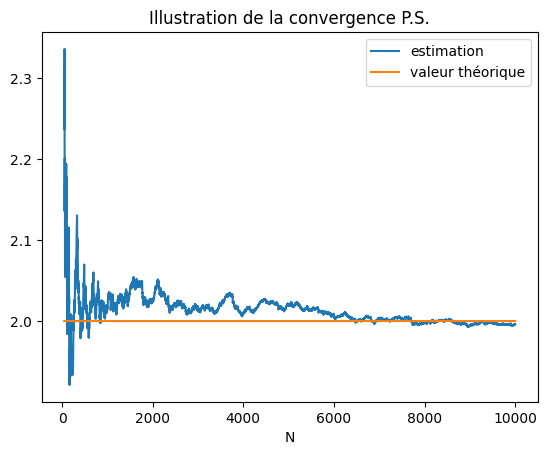

In [6]:
def illustration_cv_ps(l,n): # ATTENTION, la convergence PS s'illustre trajectoire par trajectoire !!! 
    T=stats.expon.rvs(scale=1/l, size=n)
    E=[]
    N=np.arange(50,n+1) # Je commence à 50 pour ne pas avoir trop des pics abberants aux premières valeurs qui écrasent tout le graphique
    L=[l for i in N]
    for i in N:
        estim=1/np.mean(T[:i])
        E.append(estim)
    plt.xlabel('N')
    plt.plot(N,E,label='estimation')
    plt.plot(N,L,label='valeur théorique')
    plt.title('Illustration de la convergence P.S.')
    plt.legend()
    plt.show()

illustration_cv_ps(2,10000) 

Si la convergence p.s. que vous voulez illustrer est de la forme 
$$X_n \xrightarrow[n \to \infty]{\text{p.s.}} X,$$
où $X$ est une variable NON CONSTANTE, alors il va être plus compliqué d'illustrer que la limite de $X_n$ est $X$ contrairament au cas constant. Ce que vous pouvez faire en revanche, c'est faire d'abord une illustration du fait que $X_n$ converge presque sûrement, en simulant plusieurs trajectoires pour montrer qu'elles convergent toutes, PUIS une illustration de la convergence en loi, pour au moins montrer que la limite a la même loi que $X$.

Exemple avec la martingale du TP7 : on définit 
$$M_n = \sum_{k=1}^n \frac{X_k}{k}$$
où les $(X_k)_{k \ge 1}$ sont des normales centrées réduites indépendantes. Alors $(M_n)_{n \ge 1}$ est bornée dans $L^2$, et donc converge p.s. et dans $L^2$. On peut d'abord illustrer la convergence p.s. grâce à la convergence des trajectoires. 

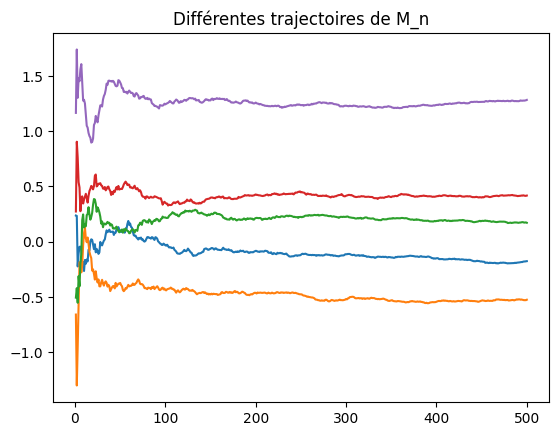

In [7]:
n=500
N=np.arange(1,n+1)
X1=np.cumsum(stats.norm.rvs(size=n)/N)
X2=np.cumsum(stats.norm.rvs(size=n)/N)
X3=np.cumsum(stats.norm.rvs(size=n)/N)
X4=np.cumsum(stats.norm.rvs(size=n)/N)
X5=np.cumsum(stats.norm.rvs(size=n)/N)
plt.plot(N,X1)
plt.plot(N,X2)
plt.plot(N,X3)
plt.plot(N,X4)
plt.plot(N,X5)
plt.title('Différentes trajectoires de M_n') 
plt.show()

Puis on montre
$$M_n \xrightarrow[n \to \infty]{\mathcal L} \mathcal{N}\left ( 0, \frac {\pi ^2}{6}\right ),$$
ce que l'on peut illustrer avec les techniques classiques d'illustration de la convergence en loi (cf partie suivante). 

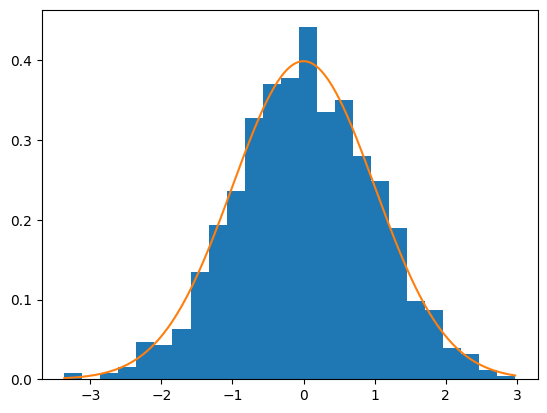

In [3]:
n=1000
N=1000
M=[]
for _ in range (N): 
    M.append(np.sum(stats.norm.rvs(size=n)/np.arange(1,n+1)))
M=(sqrt(6)/pi)*np.array(M)
plt.hist(M,25,density='True', label='histogramme échantillon')
X=np.linspace(min(M),max(M),250)
plt.plot(X,stats.norm.pdf(X),label='densité loi normale')
plt.show()

## 2.2) Illustrer une convergence en loi 

Evidemment, la convergence en loi que vous serez le plus amené.e.s à illustrer sera le théorème central limite : soit $(X_i)_{i\ge 1}$ une suite de variables aléatoires iid et $L^2$, de moyenne $\mu$ et de variance $\sigma^2$, on a alors la convergence en loi suivante:
$$\sqrt n \left(\frac{S_n}{n} - \mu \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,\sigma^2),$$
autrement dit, (formulation plus facile à illustrer numériquement) 
$$\frac{\sqrt n}{\sigma} \left(\frac{S_n}{n} - \mu \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$
C'est donc ce théorème que l'on va illustrer dans la suite. 

### 2.2.1) A l'aide de la fonction de répartition empirique 

Imaginons que l'on veuille montrer une convergence en loi de la forme 
$$E_n \xrightarrow[n \to \infty]{\mathcal L } E.  $$

Une première façon de faire est d'utiliser les fonctions de répartitions empiriques. Pour cela, on simule un échantillon de taille $N$ de variables $(E^k_n)_{1 \le k \le N}$, et puis on trace la fonction de répartition empirique des $(E_n^k)_{1 \le k \le N}$ qui est donnée par 
$$F_n^N(x)= \frac{1}{N} \sum_{k=1}^N \mathbb{1}_{E_n^k \le x },$$
que l'on compare à la fonction de répartition de $E$.
Une façon astucieuse de faire, c'est juste de tracer le vecteur $[i/N \text{ for i in range } (1,N+1)]$ en fonction de $[E^{(1)}_n, \dots, E^{(N)}_n]$, où $E^{(1)}_n, \dots, E^{(N)}_n$ est l'échantillon trié. 

Cette méthode se base sur 2 convergences. Tout d'abord, elle repose sur le fait que la convergence en loi implique la convergence des fonctions de répartition en tout point de continuité de la fonction de répartition limite (donc partout si $E$ est à densité, ce qui est le cas pour les convergences données par le TCL). Autrement dit, si l'on note $F_n$ la fonction de répartition de $(E_n^k)_{1 \le k \le N}$ (qui ont tous la même loi) et $F$ la fonction de répartition $E$ (que l'on suppose à densité), on a 
$$F_n \xrightarrow[n \to \infty]{\text{cv simple} } F. $$
Ensuite, le deuxième théorème que l'on utilise pour justifier cette méthode, c'est le théorème de Glivenko Cantelli, qui nous dit que, à $n$ fixé, lorsque $N$ tend vers l'infini, la fonction de répartition empirique $F_n^N$ converge vers la fonction de répartition $F_n$: 
$$\Vert F_n^N - F_n \Vert_ \infty \xrightarrow[N \to \infty]{\text{p.s.}} 0. $$


Illustrons, via cette méthode, le TCL dans le cas où les $(X_i)_{i \ge 1}$ suivent loi exponentielle de paramètre $\lambda$ (et donc de moyenne $\frac{1}{\lambda}$ et de variance $\frac{1}{\lambda ^2}$). Le TCL nous donne :  
$$\sqrt n \left(\frac{S_n}{n} - \frac{1}{\lambda} \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,\frac{1}{\lambda^2}). $$
Donc en appliquant la $\delta$ méthode avec la fonction $x \mapsto \frac{1}{x}$, on obtient : 
$$\sqrt n \left(\frac{n}{S_n} - \lambda \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,\lambda^2) \quad \text {i.e.} \quad \frac{\sqrt n}{\lambda} \left(\frac{n}{S_n} - \lambda \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1), $$ 
et finalement en utilisant le lemme de Slutsky on obtient, en notant $\lambda_n =\frac{n}{S_n}$ :
$$\frac{\sqrt n}{\lambda_n} \left(\lambda_n - \lambda \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$ 
Dans ce cas, 
$$E_n = \frac{\sqrt n}{\lambda_n} \left(\lambda_n - \lambda \right). $$
Et donc pour illustrer cette convergence, on simule $N$ échantillons indépendants de taille $n$ que l'on note $(X_i^k)_{1 \le i \le n }$ pour $1 \le k \le N$. Ensuite, pour chaque échantillon, on calcule 
$$E_n^k =  \frac{\sqrt n}{\lambda_n^k} \left(\lambda_n^k - \lambda \right),  $$
où $\lambda_n^k= \displaystyle \frac{n}{\displaystyle \sum_{i=1}^n X_i^k}$, et puis on applique la méthode décrite précédemment. 

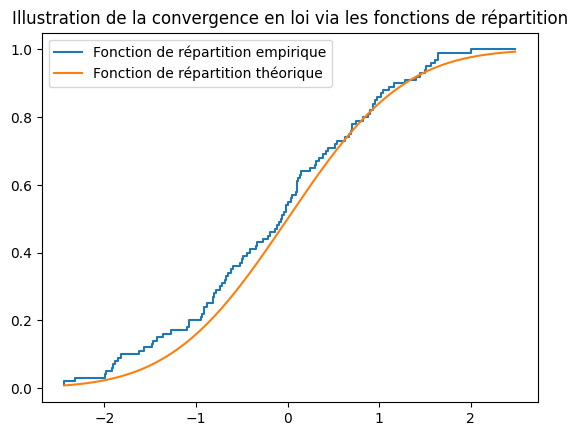

In [4]:
def illustration_cv_loi_fdr_exp(l,n,N):
    M=stats.expon.rvs(scale=1/l,size=(N,n))
    E=np.array([((sqrt(n)/((n/np.sum(M[i]))))*((n/np.sum(M[i]))-l)) for i in range (N)])
    E=np.sort(E)
    F_emp=np.arange(1,N+1)/N
    plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')
    
    X = np.linspace(min(E),max(E),500)
    F_th=stats.norm.cdf(X) # par défaut, la loi normale est la centrée réduite 
    plt.plot(X,F_th,label='Fonction de répartition théorique')
    
    plt.title('Illustration de la convergence en loi via les fonctions de répartition')
    plt.legend()
    plt.show()

illustration_cv_loi_fdr_exp(2,500,100)

Pour avoir un exemple avec des variables discrètes, voilà ci-dessous une autre illustration du TCL, cette fois dans le cas où les $(X_i)_{i \ge 1}$ suivent une loi de Bernoulli de paramètre $p$. Le TCL correspondant s'écrit 
$$\frac{S_n - np }{\sqrt{np(1-p)} } \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1), $$
Illustrons cela via la même méthode (même méthode de simulation malgré le fait que les variables de départ soient discrètes).

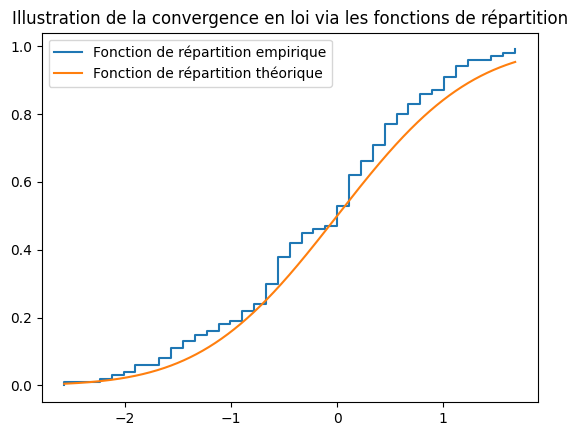

In [5]:
def illustration_cv_loi_fdr_bern(p,n,N):
    M=stats.binom.rvs(n,p,size=N) #on simule directement les sommes avec des binomiales 
    E=(M-n*p)/sqrt(n*p*(1-p))
    E=np.sort(E)
    F_emp=np.arange(N)/N
    plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')
    
    X = np.linspace(min(E),max(E),500)
    F_th=stats.norm.cdf(X,loc=0,scale=1)
    plt.plot(X,F_th,label='Fonction de répartition théorique')
    
    plt.title('Illustration de la convergence en loi via les fonctions de répartition')
    plt.legend()
    plt.show()

illustration_cv_loi_fdr_bern(0.8,500,100)

### 2.2.2) A l'aide d'histogrammes et de densité (cas continu) 

Une deuxième façon d'illustrer une convergence en loi de la forme 
$$E_n \xrightarrow[n \to \infty]{\mathcal L } E $$
dans le cas où tout le monde est à densité, c'est de comparer un histogramme empirique et une densité limite. Pour cela, on simule un échantillon de taille $N$ de variables $(E^k_n)_{1 \le k \le N}$, et cette fois, on fait un histogramme de cet échantillon que l'on compare à la densité de $E$. 

Mais ATTENTION aux affirmations concernant la convergence des histogrammes, il existe des théorèmes de convergence, mais ils ne sont pas au programme (et pas évidents), alors selon moi il est toujours bien d'avoir en plus en backup une illustration dont on sait prouver la validité (fonctions empiriques ou test de KS). Mais bon, c'est toujours joli et convaincant alors autant apprendre à faire ça bien. 

De nouveau, on commence par illustrer la convergence en loi donnée par le TCL pour des variables exponentielles, la méthode pour obtenir l'échantillon $(E^k_n)_{1 \le k \le N}$ est donc toujours la même. 

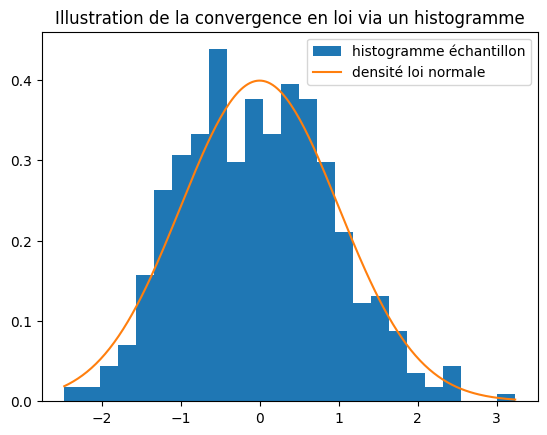

In [6]:
def illustration_cv_loi_hist_exp(l,n,N): # n est la taille des échantillons, et N le nombre des échantillons 
    M=stats.expon.rvs(scale=1/l,size=(N,n))
    L=np.array([((sqrt(n)/l)*((n/np.sum(M[i]))-l)) for i in range (N)])
    X=np.linspace(min(L),max(L),200)
    Y=stats.norm.pdf(X)
    plt.hist(L,25,density='True', label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration de la convergence en loi via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_hist_exp(2,1000,500)

Pour être rigoureux.euse, pour cette méthode il faudrait adapter la simulation dans le cas où les variables de départ sont discrètes en tracant un diagramme bâtons plutôt qu'un histogramme. Voici donc une version adaptée au cas des variables de Bernoulli. 

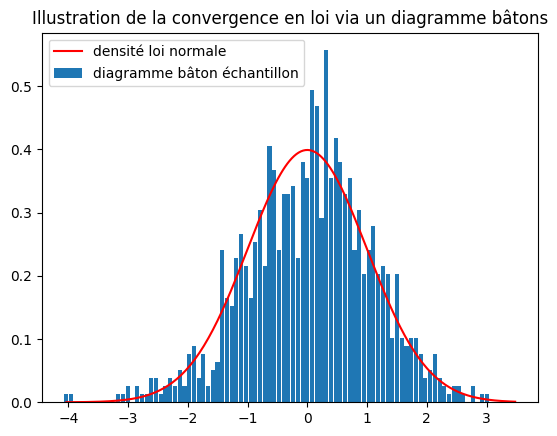

In [23]:
def illustration_cv_loi_hist_bern(p,n,N): # n est la taille des échantillons, et N le nombre des échantillons 
    S=stats.binom.rvs(n,p,size=N)
    Z=np.arange(0,n+1)
    L2=np.array([np.sum(S==z) for z in Z])
    V=(Z-n*p)/sqrt(n*p*(1-p))
    bar_width=(V[1]-V[0])
    L2=L2/(N*bar_width) # pour avoir quelque chose qui se compare bien à une densité 
    mini=np.where(L2!=0)[0][0]
    maxi=np.where(L2!=0)[0][-1]
    plt.bar(V[mini:maxi],L2[mini:maxi],bar_width-0.01,label='diagramme bâton échantillon') 
    # j'enlève le 0.01 pour que l'on voit bien qu'il s'agit d'un diagramme bâton, et non d'un histogramme (pour ne pas avoir fait tout ça pour rien...)
    # certaines bandes continuent de se coller, je n'ai pas de trouvé de réponse au pourquoi... 
    X=np.linspace(V[mini],V[maxi],200)
    Y=stats.norm.pdf(X)
    plt.plot(X,Y,'r',label='densité loi normale')
    plt.title('Illustration de la convergence en loi via un diagramme bâtons')
    plt.legend()
    plt.show()

illustration_cv_loi_hist_bern(0.8,1000,1000)  

Bon, comme vous pouvez le constater, même si ce que j'ai écrit peut sûrement être simplifié, il est tout de même plus fastidieux de tracer un diagramme bâton... et puisque le support des variables $\frac{S_n - n\mu}{\sigma \sqrt{n}}$ devient "presque" continu quand $n$ devient grand, il n'y a pas de très grande différence visuelle... Donc il vaut mieux (selon moi !) gagner du temps et faire directement un histogramme, éventuellement en se justifiant ensuite à l'oral. Exemple avec la même situation que ci dessus: 

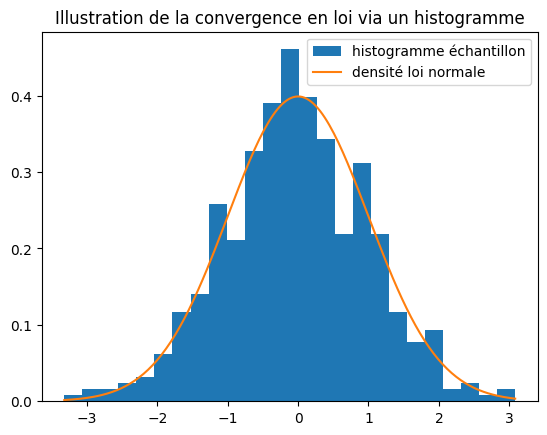

In [24]:
def illustration_cv_loi_hist_bern_de_la_flemme(p,n,N): # n est la taille des échantillons, et N le nombre des échantillons 
    S=stats.binom.rvs(n,p,size=N) #on simule directement les sommes avec des binomiales 
    L=(S-n*p)/sqrt(n*p*(1-p))
    X=np.linspace(min(L),max(L),200)
    Y=stats.norm.pdf(X)
    plt.hist(L,25,density=True,label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration de la convergence en loi via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_hist_bern_de_la_flemme(0.8,1000,500)

### 2.2.3) A l'aide de diagrammes bâtons (cas discret) 

Lorsque la loi limite est discrète, il faut cette fois obligatoirement comparer des diagrammes bâtons (cette fois, le support ne devient pas continu, donc nous ne sommes plus dans le même cas qu'avant). L'exemple typique de ce genre de convergences en loi, c'est la loi des évènements rares, qui nous dit que si $(p_n)_{n \ge 1 }$ est une suite telle que $n p_n \xrightarrow[n \to \infty]{} \lambda  > 0, $ alors 
$$ \mathcal B (n,p_n)  \xrightarrow[n \to \infty]{\mathcal L } \mathcal P (\lambda). $$
Illustrons cette loi avec $p_n = \frac{\lambda}{n}$, avec $\lambda > 0$ que l'on se fixe : on simule un échantillon $(E_n^k)_{1 \le k \le N }$ de $N$ variables indépendantes qui suivent toutes une loi $\mathcal B (n,p_n)$ avant de représenter le diagramme bâtons des fréquences empiriques correspondant, et on compare ça au diagramme bâtons des probabilités d'une loi de Poisson de paramètre $\lambda$.

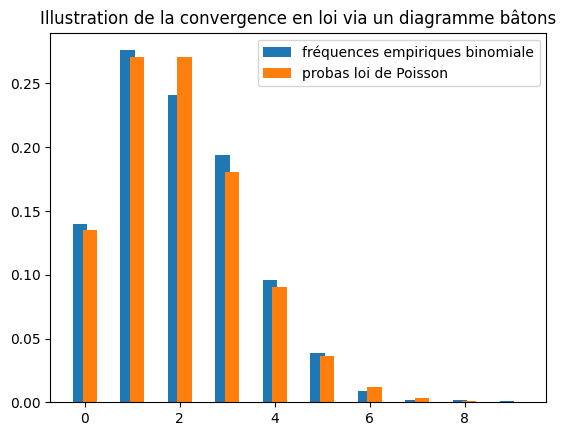

In [25]:
def illustration_cv_loi_discr(l,n,N):  
    M=stats.binom.rvs(n,l/n,size=N) 
    Z=np.arange(0,n+1)
    H_emp=np.array([np.sum(M==z)/N for z in Z])
    mini=np.where(H_emp!=0)[0][0]
    maxi=np.where(H_emp!=0)[0][-1]
    plt.bar(Z[mini:maxi+1]-0.1,H_emp[mini:maxi+1],0.3,label='fréquences empiriques binomiale')
    plt.bar(Z[mini:maxi+1]+0.1,stats.poisson.pmf(Z[mini:maxi+1],l),0.3,label='probas loi de Poisson')
    plt.title('Illustration de la convergence en loi via un diagramme bâtons')
    plt.legend() 
    plt.show()

illustration_cv_loi_discr(2,1000,1000)

### 2.2.4) A l'aide de tests 

Voir la partie consacrée aux tests ! 

# 3) Calcul à l'aide de la méthode de Monte-Carlo 

On appelle méthode de Monte-Carlo toute méthode utilisant des résultats/techniques probabilistes pour obtenir une approximation d'une valeur numérique. Grosso modo, dans nos contextes, c'est surtout quand on utilise la loi des grands nombres pour approcher une espérance (qui peut représenter une certaine proba, ou alors une intégrale qui nous intéresse ou autre). 

## 3.1) Approximation de probabilités 

Si $X$ est une variable aléatoire réelle, et $B$ un certain borélien dont on veut approximer la probabilité. On utilise alors la loi des grands nombres pour fabriquer une méthode de Monte-Carlo: la loi des grands nombres nous dit que si $(X_i)_{i \ge 1}$ est une suite de variables iid de même loi que $X$, alors 
$$\frac{1}{n} \sum_{i=1}^n \mathbb{1}_{X_i \in B} \xrightarrow[n \to \infty]{\text{p.s.}} \mathbb{E}[\mathbb{1}_{X \in B}] = \mathbb{P}(X \in B). $$
Un estimateur (sans biais et fortement consistant) de la probabilité de $B$ est donc donné par 
$$\frac{1}{n} \sum_{i=1}^n \mathbb{1}_{X_i \in B}. $$

Voyons tout d'abord un exemple bâteau pour s'entraîner: on suppose que $X$ suit une loi normale centrée réduite, et on veut obtenir la probabilité 
$\mathbb{P}(X \ge 0) $ (évidemment, on sait déjà que ça vaut $1/2$, mais il faut bien s'entraîner sur des exemples faciles). On va donc simuler un $n$-échantillon de gaussiennes centrées réduites $(X_i)_{1 \le i \le n}$, et calculer 
$$\frac{1}{n} \sum_{i=1}^n \mathbb{1}_{X_i \ge 0 }. $$

In [459]:
def approx_proba(n): 
    X=stats.norm.rvs(loc=0,scale=1,size=n) 
    return(np.mean(0<=X))

approx_proba(1000) # quelle surprise, on obtient effectivement 0.5 !

np.float64(0.509)

Bon maintenant que l'on a vu un exemple un peu nul pour se mettre en jambes, voyons un vrai exemple utile en pratique. Une situation où il peut être sympa pour un oral de modé d'utiliser la méthode de Monte-Carlo, c'est pour illustrer qu'un intervalle de confiance que l'on vient d'obtenir est effectivement au niveau souhaité. Voyons cela sur un exemple. L'exemple le plus simple d'intervalle de confiance non-asymptotique a lieu pour les gaussiennes (toujours dans les bons plans les gaussiennes) : supposons que $(X_i)_{1 \le i \le n}$ soit un $n$-échantillon de loi $\mathcal N (\mu, \sigma)$ avec $\sigma$ connu et $\mu$ inconnu, pour lequel on veut trouver un intervalle de confiance. On a: 
$$ \frac {\sqrt n}{\sigma}  \left ( \frac{1}{n} \sum_{i=1}^n X_i - \mu \right) \sim \mathcal N (0,1),$$
donc si l'on note $q_{1 - \frac{\alpha}{2}}$ le quantile d'ordre $1 - \frac{\alpha}{2}$ de la loi normale centrée réduite pour un certain niveau $\alpha >0$ que l'on fixe, alors 
$$\mathbb P \left ( \frac{1}{n} \sum_{i=1}^n X_i - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \le \mu \le \frac{1}{n} \sum_{i=1}^n X_i + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right) = 1- \alpha. $$
Ainsi, l'intervalle $\displaystyle \left [ \frac{1}{n} \sum_{i=1}^n X_i - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n }, \frac{1}{n} \sum_{i=1}^n X_i + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right]$ est un intervalle de confiance non asymptotique pour $\mu$ de niveau de confiance $1-\alpha$. 
Pour montrer fièrement au jury que l'intervalle de confiance que l'on vient de trouver est valide, on peut utiliser la méthode de Monte-Carlo: on simule $N$ échantillons indépendants de taille $n$ suivant la loi $\mathcal N (\mu, \sigma)$, avec $\mu$ connu et fixé en avance que l'on note $(X_i^k)_{1 \le i \le n}$ pour $1 \le k \le N$. Pour chaque échantillon, on calcule les deux bornes de l'intervalle: 
$$ T_{\text{inf}}^k =  \frac{1}{n} \sum_{i=1}^n X_i^k - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \quad \text{et} \quad  T_{\text{sup}}^k =  \frac{1}{n} \sum_{i=1}^n X_i^k + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n },$$
et un estimateur de 
$$ \mathbb P  \left ( \mu \in  \left [ \frac{1}{n} \sum_{i=1}^n X_i - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n }, \frac{1}{n} \sum_{i=1}^n X_i + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right] \right) $$
est donné par 
$$\frac {1}{N} \sum_{k=1}^N \mathbb{1}_{T_{\text{inf}}^k \le \mu \le T_{\text{sup}}^k}. $$
Plus qu'à le calculer, et à montrer tout fièrement que l'on obtient bien $1 - \alpha$ !

In [4]:
def intervalle_de_conf(mu,sigma,n,N,alpha): #N est le nombre d'échantillons et n est leur taille 
    P=0
    for i in range(0,N):
        X=stats.norm.rvs(loc=mu, scale=sigma,size=n)
        estim=np.mean(X)
        q=stats.norm.ppf(1-alpha/2,loc=0,scale=1)
        c=sigma*q/sqrt(n)
        borne1=estim-c
        borne2=estim+c 
        if borne1 <= mu <= borne2:
            P+=1
    return(P/N)
    
print(intervalle_de_conf(3,1,100,1000,0.05)) # Youhou, ça fonctionne !

0.937


Remarque : si l'intervalle de confiance que vous avez obtenu est un intervalle de confiance ASYMPTOTIQUE, vous pouvez aussi faire cette méthode, et pour $n$ assez grand, ça devrait donner un bon résultat. Un autre moyen d'illustrer un intervalle de confiance asymptotique, c'est de tracer l'estimateur et les bornes de l'intégrale en fonction de $n$ (pour un évènement fixé), à "la convergence p.s.". J'en ai fait un exemple dans la partie suivante. 

## 3.2) Approximation d'intégrales 

Un autre gros fond de commerce des méthodes de Monte-Carlo, c'est de calculer des intégrales, en les écrivant comme des espérances de fonctions de variables aléatoires que l'on sait simuler. Par exemple, supposons que l'on veuille calculer une intégrale de type 
$$I = \int_{\mathbb R^d} g(x) f(x) \mathrm{d} x,$$
telle que 
$$\int_{\mathbb R^d} |g(x)| f(x) \mathrm{d} x < + \infty $$
et où $f$ est une densité de probabilité. On peut estimer $I$ grâce à une méthode de Monte-Carlo qui se base de nouveau sur la loi des grands nombres: on simule un $n$ échantillon $(X_i)_{1 \le i \le n}$ de densité $f$, et un estimateur (sans biais et fortement consistant) de $I$ est donné par : 
$$I_n :=  \frac{1}{n} \sum_{i=1}^n g(X_i), $$
puisque, par la loi des grands nombres
$$I_n \xrightarrow[n \to \infty]{\text{p.s.}} \mathbb E (g(X_1))= I.$$
On peut même faire mieux, et donner un intervalle de confiance asymptotique pour $I$ grâce au théorème central limite. Celui ci nous dit que l'on a la convergence en loi suivante: 
$$\frac{\sqrt n}{\sigma} (I_n - I) \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1),$$
avec $\sigma ^2 = \mathbb E [g^2(X)]- \mathbb E [g(X)]$. Or, grâce à la loi des grands nombres, on a 
$$\sigma_n:= \frac{1}{n} \sum_{i=1}^n \left( g(X_i)- I_n \right)^2  \xrightarrow[n \to \infty]{\text{p.s.} } \sigma.$$
Ainsi, par le théorème de Slutsky, on en déduit 
$$\frac{\sqrt n}{\sigma_n} (I_n - I) \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$
On en déduit que pour un niveau $\alpha >0$, l'intervalle 
$$\left[ I_n - \frac{\sigma_n q_{1 - \frac{\alpha}{2}}}{\sqrt n }, I_n + \frac{\sigma_n q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right],$$
où $q_{1 - \frac{\alpha}{2}}$ désigne le quantile d'ordre $1 - \frac{\alpha}{2}$ de la loi normale centrée réduite, est un intervalle de confiance ASYMPTOTIQUE de niveau $1-\alpha$ pour $I$. 

Voyons un premier exemple avec l'intégrale suivante: 
$$I = \int_0^1 4 \sqrt{1-x^2} \mathrm{d} x.$$
Si $X$ suit une loi uniforme sur $[0,1]$, on a 
$$\mathbb E \left[ 4 \sqrt{1-X^2} \right]=I.$$
Ainsi, pour estimer $I$, on simule un $n$-échantillon $(X_i)_{1 \le i \le n}$ de loi uniforme sur $[0,1]$ et on calcule 
$$\frac{1}{n} \sum_{i=1}^n 4 \sqrt{1-X_i^2}. $$

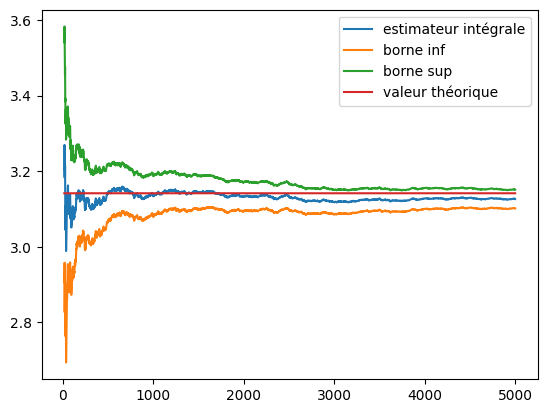

In [502]:
def g(x):
    return(4*np.sqrt(1-x**2))

def estimation_et_intervalle_integrale(N,alpha):
    S=[] #contient les estimateurs
    I1=[] #contient les bornes inf
    I2=[] #contient les bornes sup
    T=np.arange(1,N+1)
    X=stats.uniform.rvs(loc=0,scale=1,size=N)
    Y=g(X)
    for n in range(1,N+1):
        Yn=Y[:n]
        s=np.mean(Yn)
        sigma=sqrt(np.mean((Yn-s)**2))
        q=stats.norm.ppf(q=1-alpha/2,loc=0,scale=1)
        c=q*sigma/sqrt(n)
        i1=s-c
        i2=s+c
        S.append(s)
        I1.append(i1)
        I2.append(i2)
    plt.plot(T[15:],S[15:],label='estimateur intégrale') # je commence à 15 pour éviter les pics abberants des premières valeurs
    plt.plot(T[15:],I1[15:],label='borne inf')
    plt.plot(T[15:],I2[15:],label='borne sup')
    plt.plot(T[15:],pi*np.ones(len(T[15:])), label='valeur théorique')
    plt.legend()
    plt.show()

estimation_et_intervalle_integrale(5000,0.05)

Voyons un autre exemple. On souhaite cette fois calculer l'intégrale 
$$ I = \int_{\mathbb R} \cosh(x) e^{-x^2} \mathrm{d}x.$$
Si $ X \sim \mathcal N (0, \frac{1}{\sqrt 2})$, alors 
$$ \mathbb E [ \sqrt \pi \cosh X] = \int_{\mathbb R} \sqrt\pi \cosh(x) \frac{e^{-2\frac{x^2}{2}}}{\frac{1}{\sqrt 2} \sqrt{2\pi}} \mathrm{d}x = I. $$
Ainsi, pour estimer $I$, on simule un $n$-échantillon $(X_i)_{1 \le i \le n}$ de loi $\mathcal N (0, \frac{1}{\sqrt 2})$ et on calcule 
$$\frac{1}{n} \sum_{i=1}^n \sqrt \pi \cosh(X_i). $$

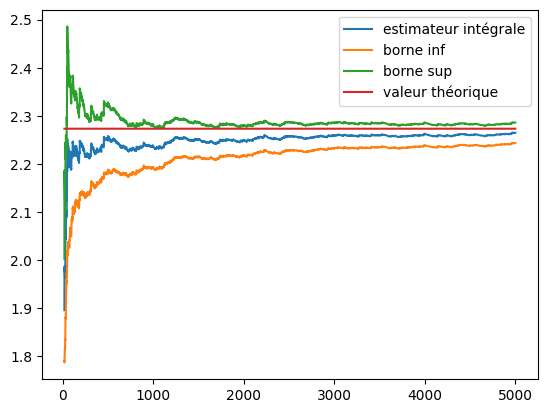

In [503]:
def h(x):
    return(sqrt(pi)*np.cosh(x))

def estimation_et_intervalle_integrale2(N,alpha):
    S=[] #contient les estimateurs
    I1=[] #contient les bornes inf
    I2=[] #contient les bornes sup
    T=np.arange(1,N+1)
    X=stats.norm.rvs(loc=0,scale=(1/sqrt(2)),size=N)
    Y=h(X)
    for n in range(1,N+1):
        Yn=Y[:n]
        s=np.mean(Yn)
        sigma=sqrt(np.mean((Yn-s)**2))
        q=stats.norm.ppf(q=1-alpha/2,loc=0,scale=1)
        c=q*sigma/sqrt(n)
        i1=s-c
        i2=s+c
        S.append(s)
        I1.append(i1)
        I2.append(i2)
    plt.plot(T[15:],S[15:],label='estimateur intégrale') # je commence à 15 pour éviter les pics abberants des premières valeurs
    plt.plot(T[15:],I1[15:],label='borne inf')
    plt.plot(T[15:],I2[15:],label='borne sup')
    plt.plot(T[15:],2.273*np.ones(len(T[15:])), label='valeur théorique')
    plt.legend()
    plt.show()

estimation_et_intervalle_integrale2(5000,0.05)

Comme on le voit sur les bornes de l'intervalle de confiance asymptotique, plus la variance de l'estimateur sera faible, meilleure sera notre estimation : il faut donc essayer de bricoler nos méthodes de Monte-Carlo pour obtenir des estimateurs à faible variance (cf TP3). Il existe des sujets de modé sur ce genre de thématiques. 

# 4) Chaînes de Markov 

Les chaînes de Markov, c'est un sujet qui tombe assez souvent à l'oral, alors même si ça peut amener à des choses très différentes de ce qui va suivre, il est tout de même bon de connaître les bases dans un cadre ""simple"". Dans la suite, on considère une chaîne de Markov $(X_k)_{k \ge 1 }$ de matrice de transition $P$ sur un espace d'états au plus dénombrable. 

## 4.1) Simuler une trajectoire 

Le programme suivant permet de simuler la trajectoire de notre chaîne de Markov, à partir de sa matrice de transition $P$, de son état initial et du nombre de pas que l'on veut dans le cas où l'espace d'états est fini. Ici, on met l'espace d'états en bijection avec $[0,len(P)-1]$. Si le cardinal de l'espace d'états est infini $(\mathbb Z$ par exemple), ou que la matrice de transition est fastidieuse à coder, il faut faire autrement ! (par exemple en utilisant une relation de récurrence, cf TP 4). 

In [3]:
def trajectoire_Markov(n,P,x0):
    X=np.zeros(n,dtype=int) #on indique que X contiendra seulement des entiers.
    X[0]=x0
    for k in range(n-1):
        X[k+1]=np.random.choice(a=range(len(P)), p=P[X[k],:])
        # Les états sont numérotés de 0 à len(P)-1
    return X

P=np.array([[1/3, 1/3, 1/6, 1/6], [0, 1/2, 0, 1/2], [1/4, 1/4, 1/4, 1/4], [1/3, 1/3, 1/3, 0]])

X=trajectoire_Markov(100,P,0)
print(X)

[0 1 1 3 2 2 3 0 3 1 3 1 3 2 2 0 1 3 0 2 2 3 0 3 2 0 0 3 1 3 1 1 1 3 2 1 3
 1 1 3 0 0 1 3 1 1 1 3 0 2 3 1 3 1 1 1 3 1 3 0 2 2 2 1 1 1 1 3 1 1 3 2 3 0
 0 0 3 0 1 1 3 1 1 3 0 1 1 1 1 1 1 3 2 2 3 0 0 3 2 1]


## 4.2) Calculer une proba invariante (3 méthodes)

### 4.2.1) Première méthode : avec la définition et grâce à l'algèbre linéaire 

Une probabilité invariante $\pi$ de la chaîne est une probabilité qui vérifie l'équation suivante : 
$$\pi P = \pi,$$
autrement dit, $\pi$ est un vecteur propre de la transposée de $P$ pour la valeur propre $1$. 

Pour toute la suite, on se donne par exemple la matrice de transition suivante (matrice de l'exo 2 du TP 4): 
$$\begin{bmatrix}
0.9 & 0.05 & 0.05 \\
0.7 & 0    & 0.3  \\
0.8 & 0    & 0.2
\end{bmatrix}. $$
La chaîne correspondante est irréductible, et ainsi tous les états sont de même nature. Etant donné que l'espace d'états est fini, les états sont tous réccurents positifs. Le coefficient $P_{1,1}$ est non nul (i.e on peut boucler sur $1$), et puisque il n'y a qu'une seule classe d'équivalence, la chaîne est apériodique.

Ici, puisque l'espace d'états est de cardinal fini, on sait qu'il existe une proba invariante. Les théorèmes généraux (i.e dans le cas au plus dénombrable) nous disent que si $P$ est irréductible, alors la chaîne admet au plus une proba invariante, et que dans ce cas, il y a équivalence entre existence d'une unique proba invariante et le fait que tous les états soient réccurents positifs (et donc avec le fait qu'il existe un état réccurent positif, ce qui est équivalent par irréductibilité). 

Dans notre cas, on a donc existence d'une unique proba invariante, et nous allons pour l'instant l'obtenir grâce à l'algèbre linéaire. 

In [506]:
P_Grib= np.array([[0.9,0.05,0.05],[0.7,0,0.3],[0.8,0,0.2]]) # c'était la matrice du chat Gribouille 

def proba_invariante1(P):
    eigVal,eigVec= np.linalg.eig(P.T)
    i=np.where(abs(eigVal-1)< 0.001)[0][0] # il faut faire attention aux erreurs de calcul etc
    p=np.real(eigVec[:,i]) # on prend le vecteur propre associé à 1, attention il est en colonne
    return(p/np.sum(p)) # attention il faut normaliser le vecteur !

pi1=proba_invariante1(P_Grib)
print(pi1)

[0.8839779 0.0441989 0.0718232]


### 4.2.2) Deuxième méthode : en utilisant la convergence en loi de la chaîne 

Les théorèmes généraux nous disent que dans le cas où la chaîne est irréductible, apériodique et réccurente positive (ce dernier point est automatique si la chaîne est irréductible sur un espace d'états fini) de mesure invariante $\pi$ (qui existe et est unique d'après ce qui précède), alors pour toute loi initiale, la chaîne converge en loi vers sa mesure invariante $\pi$, i.e. pour toute loi initiale $\nu$, 
$$ \nu P^n \xrightarrow[n \to \infty]{} \pi.$$
C'est de cette convergence dont on va se servir pour la deuxième de calcul de la proba invariante. 

[0.8839779 0.0441989 0.0718232]


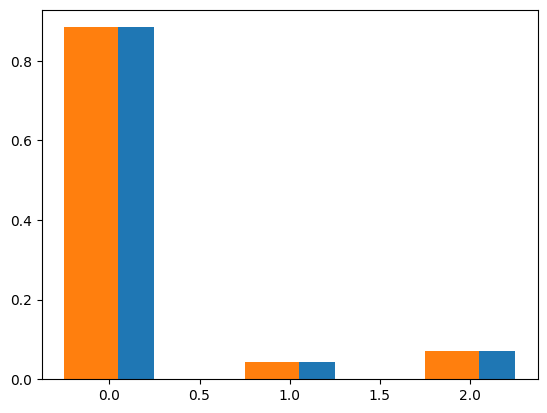

In [519]:
def proba_invariante2(P,N): 
    A=np.linalg.matrix_power(P,N)
    n=len(P)
    mu=np.ones(n)/n # on peut mettre ce que l'on veut comme loi initiale, ici je mets la loi uniforme
    return(mu.dot(A))

pi2=proba_invariante2(P_Grib,100)
print(pi2)

# on compare ce résultat à celui obtenu avec la méthode précédente 
E=np.arange(len(P_Grib))
plt.bar(E+0.1,pi1,width=0.3)
plt.bar(E-0.1,pi2,width=0.3)
plt.show()
# très bon résultat 

### 4.2.3) Troisième méthode : en utilisant le théorème ergodique 

Le théorème ergodique nous dit que si $P$ est irréductible et si la chaîne est réccurente positive (encore une fois, ce point découle de l'irréductibilité si l'on se place sur un espace d'états fini), alors pour toute loi initiale $\nu$ et pour toute fonction bornée $f$ sur l'espace d'états $E$, on a 
$$ \frac {1} {n} \sum_{k=1}^n f(X_k) \xrightarrow[n \to \infty]{\mathbb P _\nu \text{ p.s.}} \int_E f \mathrm{d} \pi, $$
où $\pi$ est l'unique proba invariante de la chaîne (qui, de nouveau, existe d'après le premier point). 
En particulier, on a pour tout état $i$ de $E$ et pour toute loi initiale $\nu$, 
$$ \frac{1}{n} \sum_{k=1}^{n} \mathbb{1}_{ \{ X_k=i \}}  \xrightarrow[n \to \infty]{\mathbb P _\nu \text{ p.s.}} \pi(i).$$
C'est de ce résultat dont on se sert pour fabriquer la troisième méthode de calcul de la proba invariante. (C'est intuitif : le vecteur des fréquences de passage converge vers la proba "stable".)

[0.888  0.0427 0.0693]


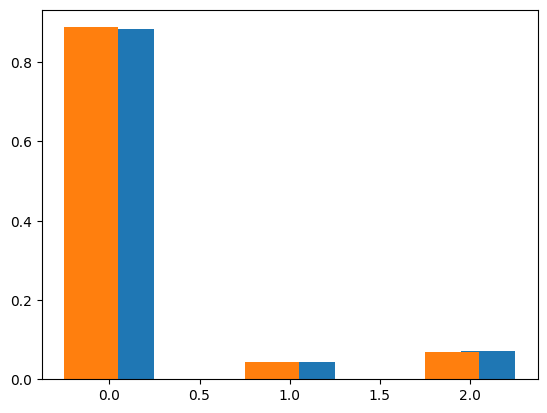

In [518]:
def proba_invariante3(n,P,x0): # ici, la loi initiale est le Dirac en x0, mais on aurait pu mettre n'importe quelle autre loi initiale
    X=trajectoire_Markov(n,P,x0)
    P=np.array([np.mean(X==i) for i in range (len(P))])
    return(P)

pi3=proba_invariante3(10000,P_Grib,0)
print(pi3)

# on compare ce résultat à celui obtenu avec la méthode précédente 
E=np.arange(len(P_Grib))
plt.bar(E+0.1,pi1,width=0.3)
plt.bar(E-0.1,pi3,width=0.3)
plt.show()
# un chouilla moins précis 

# 5) Processus de Poisson 

## 5.1) Simuler une trajectoire 

Il est possible de simuler une trajectoire de processus de Poisson de deux façons différentes : simuler ses $n$ premiers sauts ou simuler le processus jusqu'à l'instant $t$. 

Commençons par la première option. Pour faire cela, on utilise la propriété suivante : si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors on peut écrire $N_t$ sous la forme 
$$N_t = \sum_{n=1}^{+\infty} 1_{T_n \le t},$$
où la suite $(T_n)_{n \ge 1}$ de temps de sauts du processus est donnée par : 
$$T_n= \sum_{k=1}^n \tau_k,$$
où les $(\tau_k)_{k \ge 1}$ (durées inter-sauts) suivent des lois exponentielles de paramètre $\lambda$. 

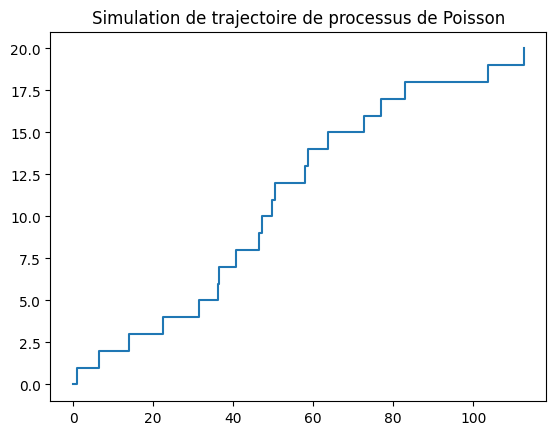

In [5]:
def trajectoire_Poisson(n,l): 
    X=stats.expon.rvs(loc=0,scale=1/l,size=n)
    T=np.array([0]+list(np.cumsum(X)))
    N=np.arange(n+1)
    plt.plot(T,N,drawstyle='steps-post')
    plt.title('Simulation de trajectoire de processus de Poisson')
    plt.show()

trajectoire_Poisson(20,1/5)
# Pour vérifier que le résultat est cohérent, il faut regarder en moyenne la fréquence des sauts 
# (ici il faut environ 100 unités de temps pour faire 20 sauts, ça paraît ok)

Voyons maintenant comment simuler une trajectoire du processus jusqu'à un instant $t$. Pour faire cela, on utilise les deux propriétés suivantes : si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors pour tout $t>0$, la variable $N_t$ suit une loi de Poisson de paramètre $\lambda t$, et sachant $N_t=n$, la loi du $n$-uplet $(T_1,\dots,T_n)$ coincide avec celle d'un $n$-échantillon ordonné de variables aléatoires iid de loi uniforme sur $[0,t]$. 

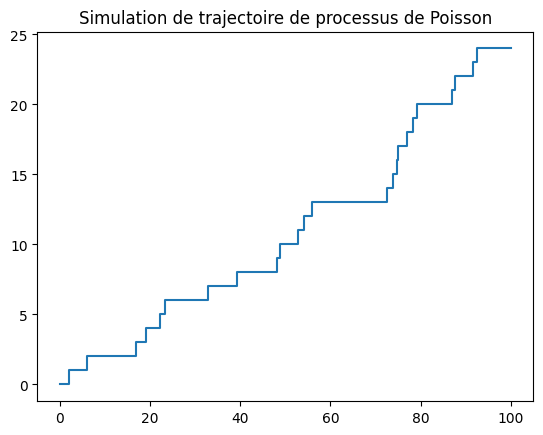

In [6]:
def trajectoire_Poisson3(t,l): 
    n=stats.poisson.rvs(mu=l*t)
    U=stats.uniform.rvs(loc=0,scale=t,size=n)
    T=[0]+list(np.sort(U))+[t]
    N=list(np.arange(n+1))+[n]
    plt.plot(T,N,drawstyle='steps-post')
    plt.title('Simulation de trajectoire de processus de Poisson')
    plt.show()

trajectoire_Poisson3(100,1/5)
# De même ici, on vérifie qu'on fait en moyenne 20 sauts en 100 unités de temps, cela paraît cohérent. 

## 5.2) Estimation du paramètre 

Pour estimer le paramètre d'un processus de Poisson, on a de nouveau deux points de vue : soit on connaît le $n$-ième temps de sauts du processus, soit on connaît le processus à un certain instant $t$.

Voyons tout d'abord le premier cadre : on connaît le $n$-ième temps de sauts du processus. La loi des grands nombres et le théorème central limite classiques appliqués aux variables $(T_n)_{n \ge 1}$ nous donne le résultat suivant. 

Si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors on a les convergences suivantes : 
$$\frac{n}{T_n} \xrightarrow[n \to \infty]{\text{p.s.}} \lambda $$
et 
$$ \sqrt n \left ( \lambda \frac {T_n}{n} - 1 \right ) \xrightarrow[n \to \infty]{\mathcal L }\mathcal{N}(0,1).$$

Illustrons ces deux convergences ! 

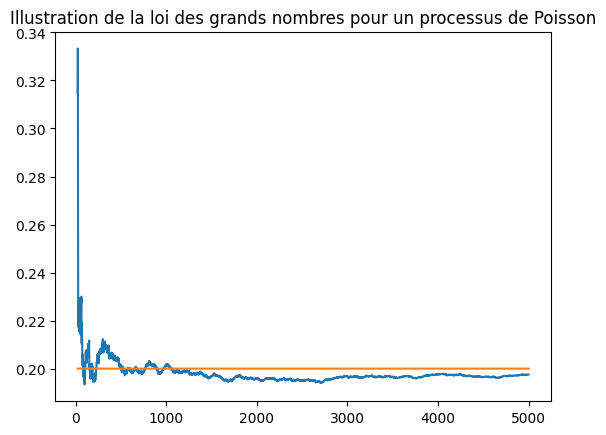

In [7]:
def illustration_cv_ps_n(l,n): 
    X=stats.expon.rvs(loc=0,scale=1/l,size=n)
    T=np.array([0]+list(np.cumsum(X)))
    N=np.arange(20,n+1)
    E=[i/T[i] for i in N]
    L=l*np.ones(len(E))
    plt.plot(N,E,label='estimateur')
    plt.plot(N,L,label='valeur théorique')
    plt.title('Illustration de la loi des grands nombres pour un processus de Poisson')
    plt.show()

illustration_cv_ps_n(1/5,5000)

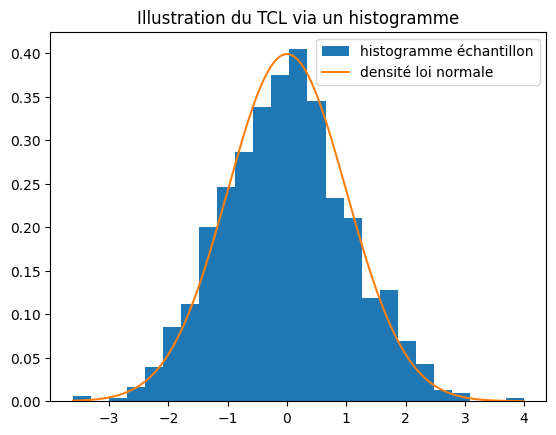

In [63]:
def illustration_cv_loi_n(n,l,N):
    H=[]
    for _ in range (N):
        X=stats.expon.rvs(loc=0,scale=1/l,size=n)
        T=np.sum(X)
        e=T/n
        h=np.sqrt(n)*(l*e-1)
        H.append(h)
    X=np.linspace(min(H),max(H),200)
    Y=stats.norm.pdf(X)
    plt.hist(H,25,density='True', label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration du TCL via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_n(1000,1/5,1000)

A partir du TCL, on peut obtenir un intervalle de confiance (asymptotique) de niveau de confiance $\alpha$ pour $\lambda$ : 
$$I_\alpha := \left [\widehat{\lambda_n}\left( 1 - \frac{q_{1 - \alpha/2}}{\sqrt n}\right ), \widehat{\lambda_n}\left( 1 + \frac{q_{1 - \alpha/2}}{\sqrt n} \right) \right ], $$
avec $\widehat{\lambda_n}:= \frac{n}{T_n}$ est l'estimateur de $\lambda$ donné par la loi des grands nombres, et où $q_{1 - \alpha/2}$ est le quantile d'ordre $1 -\frac{\alpha}{2}$ d'une loi normale centrée réduite.  
Illustrons cela ! 

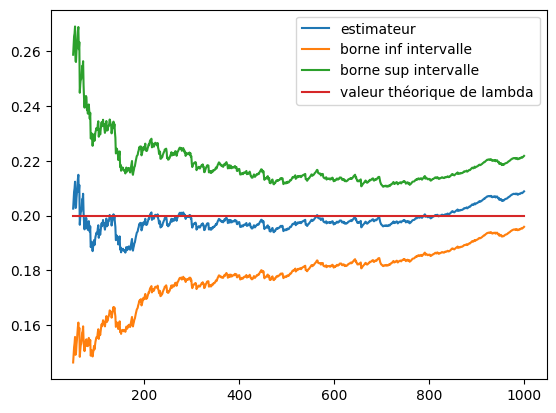

In [11]:
def illustration_intervalle_n(n,l,alpha):
    X=stats.expon.rvs(loc=0,scale=1/l,size=n)
    T=np.array([0]+list(np.cumsum(X)))
    N=np.arange(n+1)
    E=[]
    I_inf=[]
    I_sup=[]
    q= stats.norm.ppf(1-alpha/2,loc=0,scale=1)
    for k in N[50:] :
        e=k/T[k]
        E.append(e)
        i_inf=e*(1-q/np.sqrt(k))
        I_inf.append(i_inf)
        i_sup=e*(1+q/np.sqrt(k))
        I_sup.append(i_sup)
    L=l*np.ones(len(N[50:]))
    plt.plot(N[50:],E,label='estimateur')
    plt.plot(N[50:],I_inf,label='borne inf intervalle')
    plt.plot(N[50:],I_sup,label='borne sup intervalle')
    plt.plot(N[50:],L,label='valeur théorique de lambda')
    plt.legend()
    plt.show()

illustration_intervalle_n(1000,1/5,0.05)

Voyons maintenant le deuxième cadre : on suppose désormais que l'on observe le processus à un certain instant $t$. En travaillant sur les accroissements de $(N_t)_{t \ge 0}$, on obtient les théorèmes suivants. 

Si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors on a les convergences suivantes : 
$$\frac{N_t}{t} \xrightarrow[t \to \infty]{\text{p.s.}} \lambda $$
et 
$$ \sqrt{\frac{t}{\lambda}} \left ( \frac {N_t}{t} - \lambda \right ) \xrightarrow[t \to \infty]{\mathcal L }\mathcal{N}(0,1).$$

En combinant ces deux convergences avec le lemme de Slutsky, on obtient, en notant $\widehat{\lambda_t}:=\frac{N_t}{t}$ (estimateur de $\lambda$) : 
$$\sqrt{\frac{t}{\widehat{\lambda_t}}} \left ( \widehat{\lambda_t} - \lambda \right) \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1) .$$
Illustrons ces deux convergences ! 

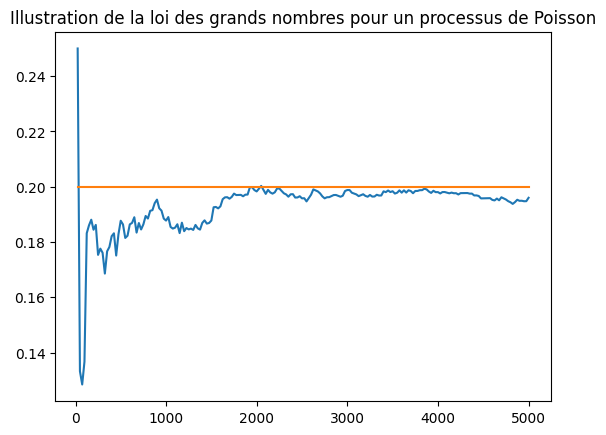

In [12]:
def illustration_cv_ps_t(l,t): 
    k=stats.poisson.rvs(mu=l*t)
    U=stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    temps=np.linspace(20,t,200)
    E=[]
    for s in temps : 
        e=np.sum([T<=s])/s
        E.append(e)
    L=l*np.ones(len(temps))
    plt.plot(temps,E,label='estimateur')
    plt.plot(temps,L,label='valeur théorique')
    plt.title('Illustration de la loi des grands nombres pour un processus de Poisson')
    plt.show()

illustration_cv_ps_t(1/5,5000)

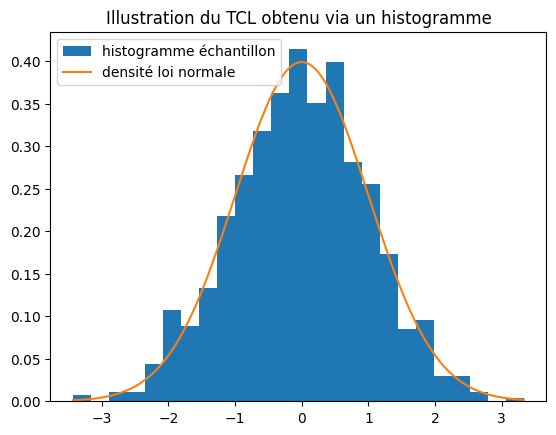

In [13]:
def illustration_cv_loi_t(t,l,N):
    H=[]
    for _ in range (N):
        k=stats.poisson.rvs(mu=l*t) # seulement besoin de Nt
        e=k/t
        h=np.sqrt(t/e)*(e-l)
        H.append(h)
    X=np.linspace(min(H),max(H),200)
    Y=stats.norm.pdf(X)
    plt.hist(H,25,density='True', label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration du TCL obtenu via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_t(1000,1/5,1000)

On peut obtenir à partir de la dernière convergence en loi un intervalle de confiance (asymptotique) de niveau de confiance $\alpha$ pour $\lambda$ : 
$$ I_\alpha := \left [  \widehat{\lambda_t} -  q_{1 - \alpha/2}\sqrt{\frac{\widehat{\lambda_t}}{t}} , \widehat{\lambda_t} + q_{1 - \alpha/2} \sqrt{\frac{\widehat{\lambda_t}}{t}}  \right ], $$
avec $\widehat{\lambda_t}:= \frac{N_t}{t}$ est un estimateur de $\lambda$, et où $q_{1 - \alpha/2}$ est le quantile d'ordre $1 -\frac{\alpha}{2}$ d'une loi normale centrée réduite. Illustrons de nouveau cet intervalle ! 

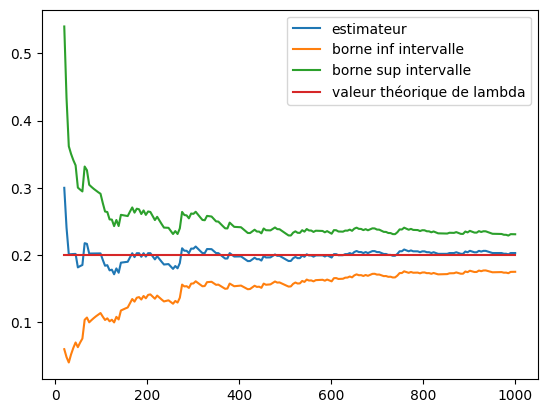

In [14]:
def illustration_intervalle_t(t,l,alpha):
    k=stats.poisson.rvs(mu=l*t)
    U=stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    temps=np.linspace(20,t,200)
    E=[]
    I_inf=[]
    I_sup=[]
    q= stats.norm.ppf(1-alpha/2,loc=0,scale=1)
    for s in temps :
        e=np.sum([T<=s])/s
        E.append(e)
        i_inf=e-np.sqrt(e/s)*q
        I_inf.append(i_inf)
        i_sup=e+np.sqrt(e/s)*q
        I_sup.append(i_sup)
    L=l*np.ones(len(temps))
    plt.plot(temps,E,label='estimateur')
    plt.plot(temps,I_inf,label='borne inf intervalle')
    plt.plot(temps,I_sup,label='borne sup intervalle')
    plt.plot(temps,L,label='valeur théorique de lambda')
    plt.legend()
    plt.show()

illustration_intervalle_t(1000,1/5,0.05)

## 5.3) Processus de Poisson composé

Une extension assez simple du processus de Poisson est le processus de Poisson composé. Ses propriétés sont proches du processus de Poisson classique, et les simulations ne sont pas beaucoup plus compliquées ! 

Soit $(\tau_k)_{k \ge 1}$ une suite de variables iid de loi exponentielle de paramètre $\lambda$ et soit $(Y_n)_{n \ge 1}$ une suite de variables iid de loi $\nu$ indépendante de la suite $(\tau_k)_{k \ge 1}$. On définit 
$$T_n = \sum_{k=1}^n \tau_k.$$ 
On appelle processus de Poisson composé d'intensité $\lambda$ et de loi de saut $\nu$ le processus $(X_t)_{t \ge 0}$ partant de 0 et défini par 
$$X_t := \sum_{n=1}^{+\infty } Y_n 1_{T_n \le t}.$$

On remarque que l'on peut réécrire $X_t$ sous la forme : 
$$X_t = \sum_{n=1}^{N_t } Y_n,$$
où 
$$N_t := \sum_{n=1}^{+\infty} 1_{T_n \le t}$$
est un processus de Poisson d'intensité $\lambda$. 

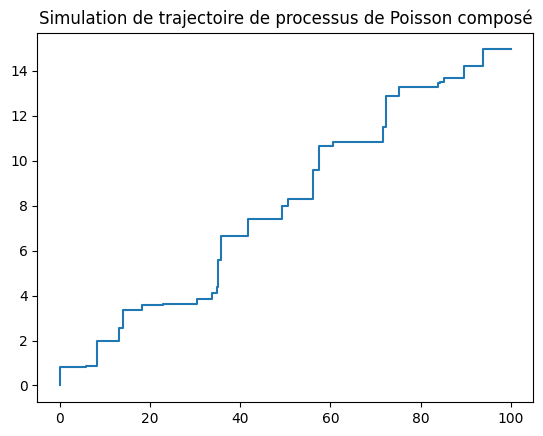

In [15]:
def trajectoire_Poisson_composé_expo(t,l,m,b): # simule une trajectoire de pP composé de loi de saut exponentielle jusqu'à l'étape t
    k=stats.poisson.rvs(mu=l*t)
    U=stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    Y=stats.expon.rvs(scale=1/m, size=k)
    X=np.array([0]+list(np.cumsum(Y))+[np.sum(Y)])
    if b==1:
        plt.plot(T,X,drawstyle='steps-post')
        plt.title('Simulation de trajectoire de processus de Poisson composé')
        plt.show()
    else :
        return(T,X)

trajectoire_Poisson_composé_expo(100,1/3,2,1)

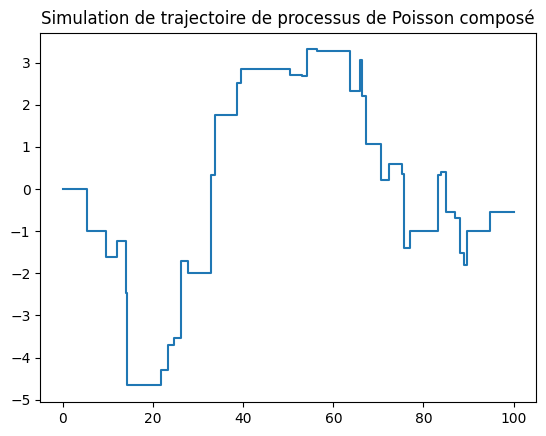

In [16]:
def trajectoire_Poisson_composé_normale(t,l,m,sigma,b): # simule une trajectoire de pP composé de loi de saut normale jusqu'à l'étape t
    k=stats.poisson.rvs(mu=l*t)
    U=stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    Y=stats.norm.rvs(loc=m,scale=sigma, size=k)
    X=np.array([0]+list(np.cumsum(Y))+[np.sum(Y)])
    if b==1:
        plt.plot(T,X,drawstyle='steps-post')
        plt.title('Simulation de trajectoire de processus de Poisson composé')
        plt.show()
    else :
        return(T,X)

trajectoire_Poisson_composé_normale(100,1/3,0,1,1)

# 6) Les tests (non paramétriques)

Avant de rentrer en détails dans les tests, voyons quelques commentaires sur la méthodologie. Chacun des tests qui va suivre se base sur le calcul d'une certaine statistique $D_n$ dépendant de notre échantillon, dont l'on connait la loi (parfois asymptotiquement) sous $H_0$, et la la zone de rejet d'un test de niveau $\alpha$ sera alors construite de la façon suivante : 
$$R_\alpha = \{ D > s_\alpha \},$$
où $s_\alpha$ est le quantile d'ordre $1 - \alpha$ de la loi de $D_n$ sous $H_0$. 

Une autre façon de construire un test de niveau $\alpha$, c'est d'utiliser la p-valeur. Mais avant de l'utiliser, il faut déjà savoir ce qu'elle représente ! De façon générale (peu importe la tête de la zone de rejet), la p-valeur est le plus petit seuil pour lequel on rejette l'hypothèse $H_0$ avec notre échantillon, autrement dit, 
$$p = \inf \{\alpha \in [0,1], D_n \in R_\alpha \}.$$
Dans le cas d'une zone de rejet de la forme de celles que l'on considère, la p-valeur s'interprète comme la probabilité d'obtenir, sous $H_0$, une valeur de $D_n$ au moins aussi grande que celle que l'on a obtenue. Ainsi, obtenir une p-valeur toute petite incite à rejeter : sous $H_0$, la probabilité d'obtenir une valeur si grande de $D_n$ est toute petite, donc $H_0$ n'est probablement pas vérifiée. 

Pour définir un test de niveau $\alpha$ en utilisant cette p-valeur, on définit la zone de rejet par 
$$R_\alpha = \{ p \le \alpha \}.$$ 
Les deux tests ne sont pas équivalents : si l'on rejette avec le premier, on rejette forcément avec le deuxième, mais il peut arriver de rejeter avec le test fourni par la p-valeur, sans pour autant rejeter avec le test fourni par la statistique. 

## 6.1) Tests du $\chi^2$

Le premier test auquel on s'intéresse est le test d'adéquation à une loi de probabilité. On considère un $n$-échantillon $X_1, \dots, X_n$ à valeurs dans $\{1,\dots,k\}$ de loi $p$, et on veut tester $H_0 : p=p^*$ contre $H_1 : p \neq p^*$. On définit alors la statistique : 
$$ D_n := \sum_{i=1}^k \frac{(N_i(n) - np^*_i)^2}{np^*_i},$$
avec $N_i(n)= \# \{ j \in \{1,\dots,n \}, X_j =i \}$. 
Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $k-1$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2(k-1)$, et on obtient un test de niveau asymptotique $\alpha$. 

Les packages Python nous fournissent aussi la p-valeur du test, et alors on peut aussi utiliser $R_\alpha = \{p \le \alpha\}$ comme zone de rejet. 

Ce test est à la base conçu pour des lois à support fini mais peut s'étendre au cas de lois discrètes sur $\mathbb{N}$ en regroupant des cases. Dans tous les cas, il faut vérifier le critère suivant : $n \times \displaystyle \min_{1 \le i \le k} p^*_i \ge 5$. 

In [57]:
# Voyons un exmple pour une loi de Poisson 
l=4
n=500
m=10
alpha=0.05
I=np.arange(m)
Pm=stats.poisson.pmf(I, mu=l)
print([n*Pm>=5]) # on choisit m pour ne pas avoir à regrouper de cases (il faut un vecteur de True)
P_th=np.array(list(Pm)+[1-np.sum(Pm)]) # on regroupe après m

X=stats.poisson.rvs(mu=l,size=n) 
I2=np.arange(max(X)+1)
F=np.array([np.mean(X==i) for i in I2])
P_emp=np.array(list(F[:m])+[np.sum(F[m:])]) # on regroupe après m également

D,p=stats.chisquare(n*P_emp,n*P_th)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha, df=len(I)-1)
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])]
On ne rejette pas H0
0.6595211598090277
On ne rejette pas H0


Le deuxième test auquel on s'intéresse est le test d'adéquation à une famille de lois. On veut cette fois tester $H_0 : p\in \{p(\theta), \theta \in \Theta\}$ contre $H_1 : p\notin \{p(\theta), \theta \in \Theta\}$, avec $\Theta \subset \mathbb{R}^d$. On définit alors la statistique : 
$$ D_n := \sum_{i=1}^k \frac{(N_i(n) - np_i(\widehat{\theta_n}))^2}{ np_i(\widehat{\theta_n})},$$
où $\widehat{\theta_n}$ est l'estimateur du max de vraisemblance de $\theta$. 
Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $k-d-1$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2(k-d-1)$, et on obtient un test de niveau asymptotique $\alpha$. 

Concrètement, il suffit d'utiliser le test précédent, en faisant un test d'adéquation à une loi, celle dont le paramètre est donné par le max de vraisemblance. 

In [3]:
l=4
n=500
alpha=0.05

X=stats.poisson.rvs(mu=l,size=n)
l_hat = np.mean(X)
print(l_hat)

m=10
I=np.arange(m)
Pm=stats.poisson.pmf(I, mu=l_hat)
print([n*Pm>=5]) # on choisit m pour ne pas avoir à regrouper de cases (il faut un vecteur de True)
P_th=np.array(list(Pm)+[1-np.sum(Pm)]) # on regroupe après m également

 
I2=np.arange(max(X)+1)
F=np.array([np.mean(X==i) for i in I2])
P_emp=np.array(list(F[:m])+[np.sum(F[m:])]) # on regroupe après m

D,p=stats.chisquare(n*P_emp,n*P_th)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha, df=len(I)-2) # attention à bien faire -d ici, où d est la dimension de l'espace du paramètre, ici 1 
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

4.122
[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])]
On ne rejette pas H0
0.2213714256544591
On ne rejette pas H0


Cette fois, on va s'intéresser à un test d'indépendance, donc le cadre change. On considère désormais un échantillon $(Z_1, \dots, Z_n)=((X_1,Y_1), \dots, (X_n,Y_n))$ de copies indépendantes d'un couple $(X,Y)$ à valeurs dans $\{1,\dots,r\} \times \{1,\dots,s\}$, et on cherche à tester $H_0$ : "$X$ et $Y$ sont indépendantes" contre $H_1$ : "$X$ et $Y$ ne sont pas indépendantes". On considère alors la statistique : 
$$D_n := \sum_{i=1}^r \sum_{j=1}^s \frac{\left ( N_{i,j} - \frac{N_{i,.} N_{.,j}}{n} \right)^2}{ \frac{N_{i,.} N_{.,j}}{n}},$$
où $N_{i,j}= \# \{ k \in \{1, \dots, n\}, X_k= i , Y_k=j\}$, $\displaystyle N_{i,.}= \sum_{j=1}^s N_{i,j}$ et $\displaystyle N_{.,j}= \sum_{i=1}^r N_{i,j}$.
Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $(r-1)(s-1)$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2((r-1)(s-1))$, et on obtient un test de niveau asymptotique $\alpha$. 

In [67]:
n=50
r=4
s=4
alpha=0.05

L=stats.randint.rvs(low=0,high=4,size=(n,2))
F=np.zeros((r,s)) # F va être la matrice des 
for i in range(n):
    (x,y)=L[i]
    F[x,y]+=1

D, p_valeur, dlib, expected=stats.chi2_contingency(F)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha,df=(r-1)*(s-1))
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

On ne rejette pas H0
0.9638858959334912
On ne rejette pas H0


Le dernier test qui nous intéresse est un test d'homogénéité. Le cadre change de nouveau : cette fois, on dispose de $l$ échantillons $E_1, \dots, E_l$ à valeurs dans $\{1,\dots,k\}$ et on veut tester $H_0 :$ "les échantillons sont tous de même loi" contre $H_1$ le complémentaire de $H_0$. On définit la statistique : 
$$D_n := \sum_{i=1}^k \sum_{j=1}^l \frac{\left ( O_{i,j} - \frac{O_{i,.}O_{.,j}}{n}\right)^2 }{\frac{O_{i,.}O_{.,j}}{n}},$$
où $O_{i,j} = \# \{x \in E_j, x=i\}$, $O_{i,.}= \displaystyle \sum_{j=1}^l O_{i,j}$, $O_{.,j}= \displaystyle \sum_{i=1}^k O_{i,j}$ et $ n = \displaystyle \sum_{j=1}^l O_{.,j}$. Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $(k-1)(l-1)$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2((k-1)(l-1))$, et on obtient un test de niveau asymptotique $\alpha$. 

In [73]:
alpha=0.05
k=10
l=3
E1= stats.randint.rvs(low=0, high=10, size=200)
E2= stats.randint.rvs(low=0, high=10, size=200)
E3= stats.randint.rvs(low=0, high=10, size=200)

D,p_value=scipy.stats.friedmanchisquare(E1,E2,E3)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha,df=(k-1)*(l-1))
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p_value)
if p_value<alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

# sans surprise, on ne rejette pas !

On ne rejette pas H0
0.795330688869839
On ne rejette pas H0


## 6.2) Tests de Kolmogorov-Smirnov

Voyons maintenant le test de Kolmogorov-Smirnov. Selon moi, ce test est LE PLUS IMPORTANT A CONNAITRE. Celui-ci est utilisé pour des lois ayant une fonction de répartition continue, et un cadre récurrent où il peut servir, c'est l'illustration de TCL, nous verrons ça dans la partie suivante. 

Le test de K.S. le plus important à connaître, c'est le test d'adéquation à une loi. On considère un $n$-échantillon $X_1, \dots, X_n$ de loi $p$, et on veut tester $H_0 : p=p^*$ contre $H_1 : p \neq p^*$. On suppose que $p$ et $p^*$ sont deux lois dont les fdr sont continues. (ATTENTION, cette condition est restrictive !!) On note $F$ la fonction de répartition de la loi $p^*$, et $F_n$ la fonction de répartition empirique de l'échantillon définie par :
$$ F_n(t) = \frac{1}{n} \sum_{i=1}^n 1_{X_i \le t}.$$
L'idée est de regarder la variable suivante : 
$$ \Vert F_n - F \Vert_\infty. $$
En fait, il y a deux versions du test de KS : une non aysmptotique et une non asymptotique. 

### 1) Test non asymptotique 

En utilisant le fait que $F$ est continue et croissante, et que $F_n$ est continue par morceaux, avec des sauts en les $X_{i}$, on peut écrire : 
$$D_n:= \Vert F_n - F \Vert_\infty = \max_{1 \le i \le n} \max \left ( \left | \frac {i}{n} - F(X_{(i)}) \right | , \left| \frac {i-1}{n} - F(X_{(i)}) \right | \right ), $$
où $(X_{(1)}, \dots, X_{(n)})$ est l'échantillon trié. (Le graphique à venir sert à se convaincre de cette expression.)

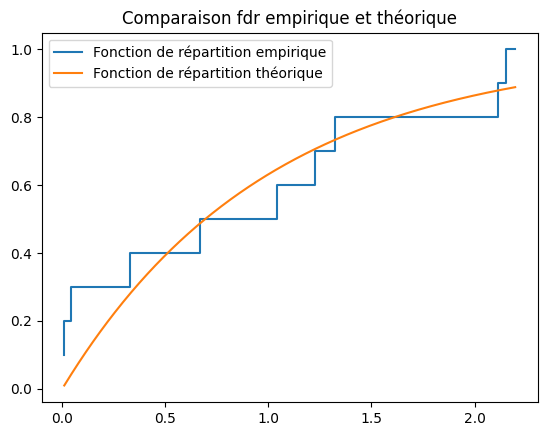

In [83]:
N=10
E=stats.expon.rvs(size=N) # par défaut, scale=1
E=np.sort(E)
F_emp=np.arange(1,N+1)/N
plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')    

X=np.linspace(min(E),max(E),500)
F_th=stats.expon.cdf(X) # par défaut, la loi normale est la centrée réduite 
plt.plot(X,F_th,label='Fonction de répartition théorique')
plt.title('Comparaison fdr empirique et théorique')
plt.legend()
plt.show()

D'une part, cette expression permet de calculer cette statistique, et d'autre part, cela permet de montrer que sous l'hypothèse nulle, la loi de cette statistique ne dépend pas de $p$. En effet, sous $H_0$, les $F(X_i)$ suivent des lois uniformes sur $[0,1]$, et puisque $F$ est croissante, l'échantillon $(F(X_{(1)}), \dots, F(X_{(n)}))$ suit la même loi qu'un échantillon trié de $(U_{(1)},\dots, U_{(n)})$ de loi uniforme sur $[0,1]$. Finalement, 
$$D_n \overset{\mathcal{L}}{=} \max_{1 \le i \le n} \max \left ( \left | \frac {i}{n} - U_{(i)} \right | , \left| \frac {i-1}{n} - U_{(i)} \right | \right )=: \mathbb{U}_n, $$
et la loi de $\mathbb{U}_n$ ne dépend pas de $p$ ! On dit que la statistique $D_n$ est libre de $p$. On peut (grâce à la méthode de Monte-Carlo) calculer les quantiles de cette loi, et cela permet d'obtenir un test.  On définit comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ de la loi de $\mathbb{U}_n$, et on obtient un test de niveau $\alpha$ (NON ASYMPTOTIQUE !).

### 2) Test asymptotique 

Un autre résultat fournit un autre test, cette fois asymptotique. En effet, si l'on définit cette fois la statistique 
$$D_n := \sqrt n \Vert F_n - F \Vert _\infty,$$
alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi appelée loi de Kolmogorov dont la fdr (évidemment pas à retenir !) est donnée par : 
$$G(t):= \mathbb{P}(K \le t ) = 1 - 2\sum_{k=1}^{+ \infty} (-1)^{k-1} e^{-2k^2t^2},$$
et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+ \infty$. On définit alors comme zone de rejet $R = \{ D_n > q_{1-\alpha}\}$, où $q_{1-\alpha}=G^{-1}(1-\alpha)$, et on obtient un test de niveau ASYMPTOTIQUE $\alpha$. 

L'avantage du test non asymptotique, c'est qu'il est valide peu importe la taille de l'échantillon. En pratique (sur Python par exemple), c'est le test asymptotique qui prend le relais pour $n>100$. On passe au test asymptotique parce que l'on ne peut pas tabuler la loi de $\mathbb{U}_n$ pour tous les $n$ possibles... 

### 3) Mise en pratique

Dans les faits, on demande à Python de faire le test avec le module consacré, et il fait lui même sa tambouille asymptotique ou non (mais il est bien de savoir expliquer comment ça marche quand même !). 

In [93]:
alpha=0.05
l=2
Y=stats.expon.rvs(scale=1/l, size=1000)
# Mon astuce, c'est de renormaliser les variables pour ne pas avoir à le faire dans le cdf du test 
# Par exemple ici, l'échantillon suit une loi exponentielle de paramètre l, alors l fois l'échantillon suit une exponentielle de paramètre 1 
D, p_valeur=stats.kstest(l*Y, stats.expon.cdf)
print(p_valeur)
if p_valeur<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

0.6627698365265033
On ne rejette pas H0


### 4) Homogénéité et autres

On peut aussi définir un test d'homogénéité de Kolmogorov : supposons que l'on dispose de deux échantillons $(X_1,\dots,X_n)$ et $(Y_1, \dots, Y_m)$ de lois respectives $p_X$ et $p_Y$ dont les fdr sont supposées continues. On souhaite tester $H_0 : p_X = p_Y$ contre $H_1 : p_X \neq p_Y $. On note $F_n$ et $G_m$ leurs fonctions de répartition respectives. On définit la statistique : 
$$D_{n,m}:= \sqrt {\frac{mn}{n+m} } \Vert F_n - G_m \Vert_\infty.$$
Alors sous l'hypothèse $H_0$, $D_{n,m}$ converge en loi vers la loi de Kolmogorov de fdr $G$ (définie précédemment), et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+ \infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}=G^{-1}(1-\alpha)$, et on obtient un test de niveau asymptotique $\alpha$. 

In [124]:
alpha=0.05
E1=stats.expon.rvs(scale=1, size=200)
E2=stats.expon.rvs(scale=1, size=200)

D,p_value=scipy.stats.ks_2samp(E1,E2)
print(p_value)
if p_value<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

0.7933622419382523
On ne rejette pas H0


Comme pour le test du $\chi^2$, il existe aussi des adaptations du test de KS, par exemple pour l'adéquation à une famille de lois, mais il y a quelques subitilités... 

## 6.3) Applications de ces tests (important !) 

En pratique, dans un texte de modé, un bon cadre pour utiliser les tests est l'illustration de théorème limite. C'est joli, et très convainquant, de faire un histogramme ou un tracé de comparaison fdr empirique/théorique, mais faire un test, ça permet de quantifier les choses ! 

Imaginons que l'on veuille illustrer une convergence en loi de la forme 
$$E_n \xrightarrow[n \to \infty]{\mathcal L }  E.$$
Pour cela, on simule un $N$-échantillon de même loi que $E_n$ (même stratégie qu'une illustration avec un histogramme par exemple), puis on fait un test d'adéquation à une loi pour cette échantillon. Si la loi limite est discrète, on utilise plutôt un test du $\chi^2$, et si la loi limite est continue, on utilise plutôt le test de KS. 

L'exemple TYPIQUE où c'est génial d'utiliser un test, c'est l'illustration d'un TCL. Pour peu que vous savez expliquer comment marcher le test de KS pendant les questions, vous allez passer pour une personne SUPER savante sans trop de difficultés. 

Par exemple, on veut illustrer le TCL pour des variables $(X_i)_{i \ge 1}$ exponentielles de paramètre $\lambda$ : 
$$E_n := \sqrt n \left(\lambda\frac{S_n}{n} - 1 \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$
Pour cela, on simule un $N$-échantillon de variables $(E_n^k)_{1 \le k \le N}$, et puis on réalise un test d'adéquation de KS à une loi normale pour cet échantillon. 

In [108]:
alpha=0.05
N=100
n=500
M=stats.expon.rvs(scale=1/l,size=(N,n))
E=np.array([((sqrt(n)/l)*((n/np.sum(M[i]))-l)) for i in range (N)])
D,p_valeur=stats.kstest(E,stats.norm.cdf)
print(p_valeur)
if p_valeur<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")
# Tout le monde est convaincu :) 

0.5979744496034974
On ne rejette pas H0


Voyons maintenant un exemple de loi limite discrète avec la loi des évènements rares, qui nous dit que si $(p_n)_{n \ge 1 }$ est une suite telle que $n p_n \xrightarrow[n \to \infty]{} \lambda  > 0, $ alors 
$$ \mathcal B (n,p_n)  \xrightarrow[n \to \infty]{\mathcal L } \mathcal P (\lambda). $$
On simule un $N$-échantillon $(E_n^k)_{1 \le k \le N }$ de variables indépendantes qui suivent toutes une loi $\mathcal B (n,p_n)$ et puis on réalise un test d'adéquation du $\chi ^2$ à une loi de Poisson de paramètre $\lambda$ pour cet échantillon. 

In [4]:
alpha=0.05
N=500
n=500
l=4
E=stats.binom.rvs(n,l/n,size=N) 

m=10
I=np.arange(m)
Pm=stats.poisson.pmf(I, mu=l)
print([N*Pm>=5]) # attention, ici c'est N la taille de l'échantillon 
P_th=np.array(list(Pm)+[1-np.sum(Pm)]) # on regroupe après m 

I2=np.arange(max(E)+1)
F=np.array([np.mean(E==i) for i in I2])
P_emp=np.array(list(F[:m])+[np.sum(F[m:])]) # on regroupe après m également

D,p=stats.chisquare(N*P_emp,N*P_th)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha, df=len(I)-1)
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

# De nouveau, tout le monde est convaincu :) 

[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])]
On ne rejette pas H0
0.7503636735656237
On ne rejette pas H0


Le test du $\chi^2$ est plus fastidieux à cause des histoires de cases à vérifier... Contrairement au test de KS qui ne mange pas de pain une fois que vous avez déjà obtenu un échantillon pour un histogramme/une fonction de répartition empirique !!